In [1]:
import os   
%pwd
os.chdir("../")
%pwd


'c:\\Users\\danm\\Documents\\DLOps_Project'

In [2]:
import pandas as pd

df = pd.read_csv('artifacts/data_ingestion/household_power_consumption.txt', sep=';', na_values=['?'], low_memory=False)
df.head()


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


In [4]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df.drop(['Date', 'Time'], axis=1, inplace=True)
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [5]:
df.isnull().sum()

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
Datetime                     0
dtype: int64

In [6]:
df.isnull().sum()/len(df) * 100  # Percentage of missing values

Global_active_power      1.251844
Global_reactive_power    1.251844
Voltage                  1.251844
Global_intensity         1.251844
Sub_metering_1           1.251844
Sub_metering_2           1.251844
Sub_metering_3           1.251844
Datetime                 0.000000
dtype: float64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.set_index('Datetime', inplace=True)
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [9]:
# Handle Missing Values
print("Missing values before processing:\n", df.isna().sum())

# For time series, interpolation (filling gaps based on surrounding data) is highly effective.
# 'time' method interpolates based on the time index distance.
df = df.interpolate(method='time')

# If there are missing values at the very beginning of the dataset, interpolation won't catch them.
# We use backfill for those edge cases.
df.bfill(inplace=True) 

print("\nMissing values after processing:\n", df.isna().sum())

Missing values before processing:
 Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Missing values after processing:
 Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


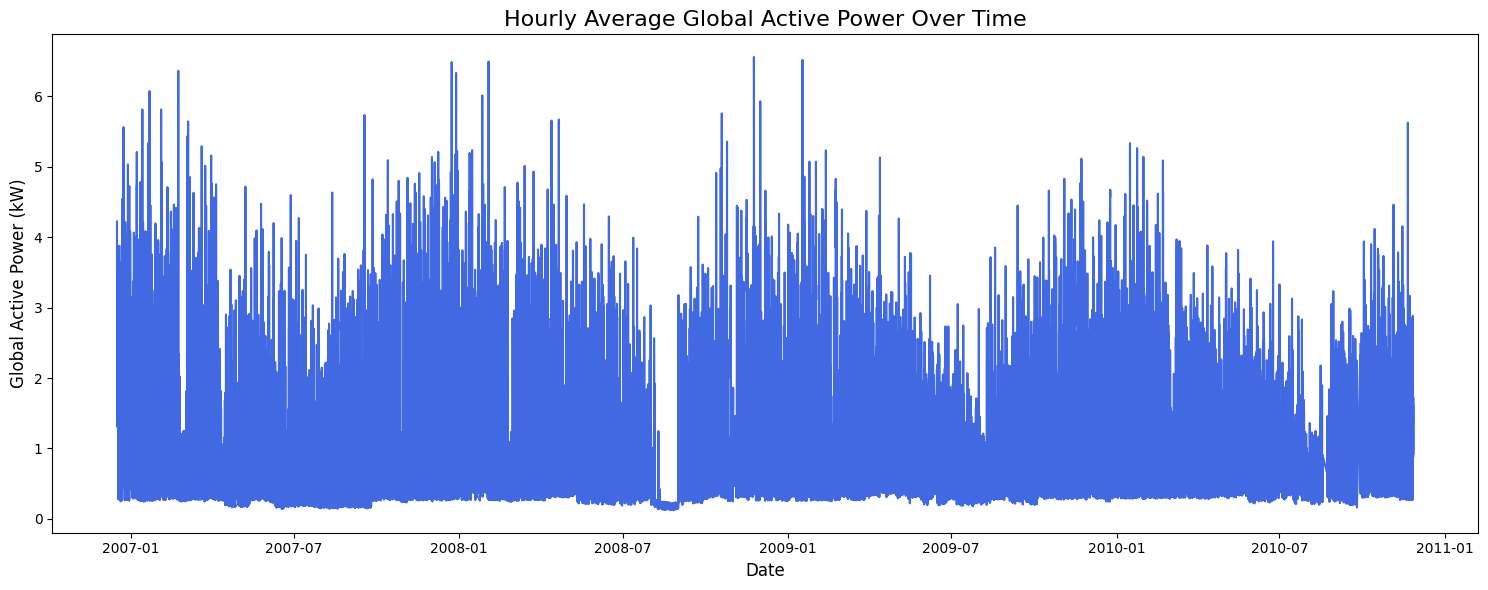

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 6))
# Resample data to hourly ('h') frequency and calculate the mean
daily_data = df['Global_active_power'].resample('h').mean()

plt.plot(daily_data.index, daily_data.values, color='royalblue', linewidth=1.5)
plt.title('Hourly Average Global Active Power Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Global Active Power (kW)', fontsize=12)
plt.tight_layout()
plt.show()

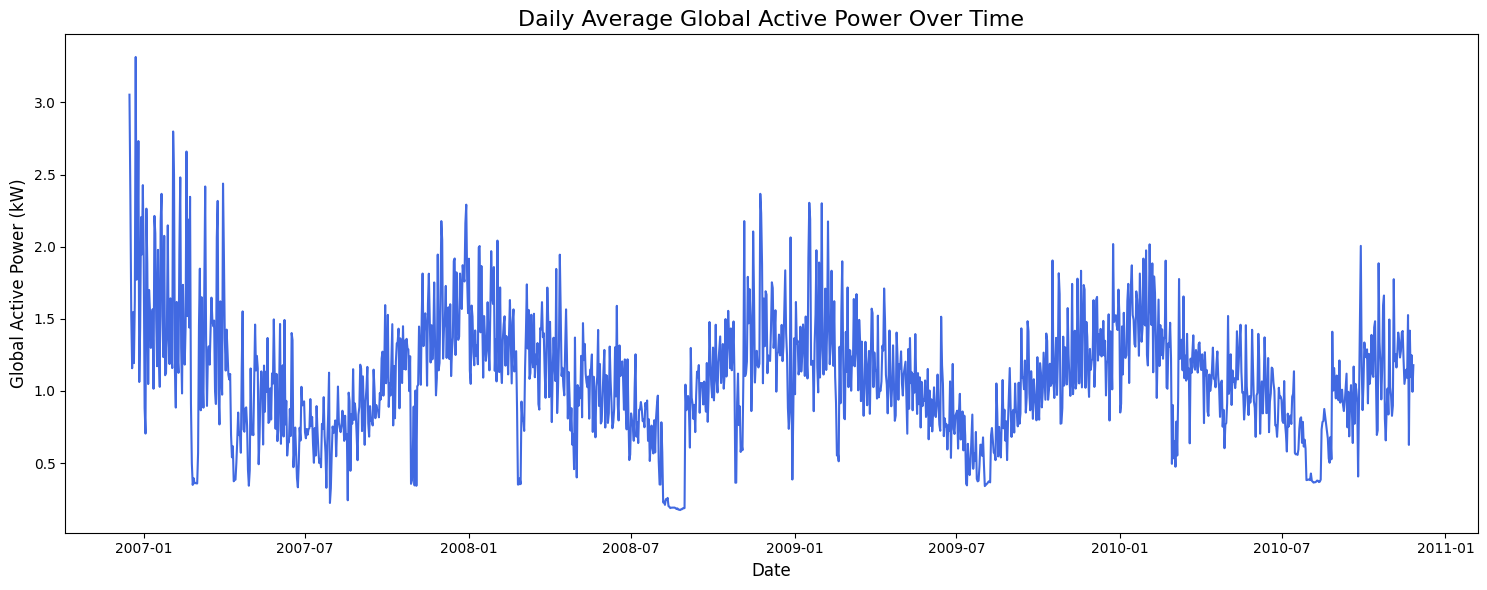

In [11]:
plt.figure(figsize=(15, 6))
# Resample data to Daily ('D') frequency and calculate the mean
daily_data = df['Global_active_power'].resample('D').mean()

plt.plot(daily_data.index, daily_data.values, color='royalblue', linewidth=1.5)
plt.title('Daily Average Global Active Power Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Global Active Power (kW)', fontsize=12)
plt.tight_layout()
plt.show()

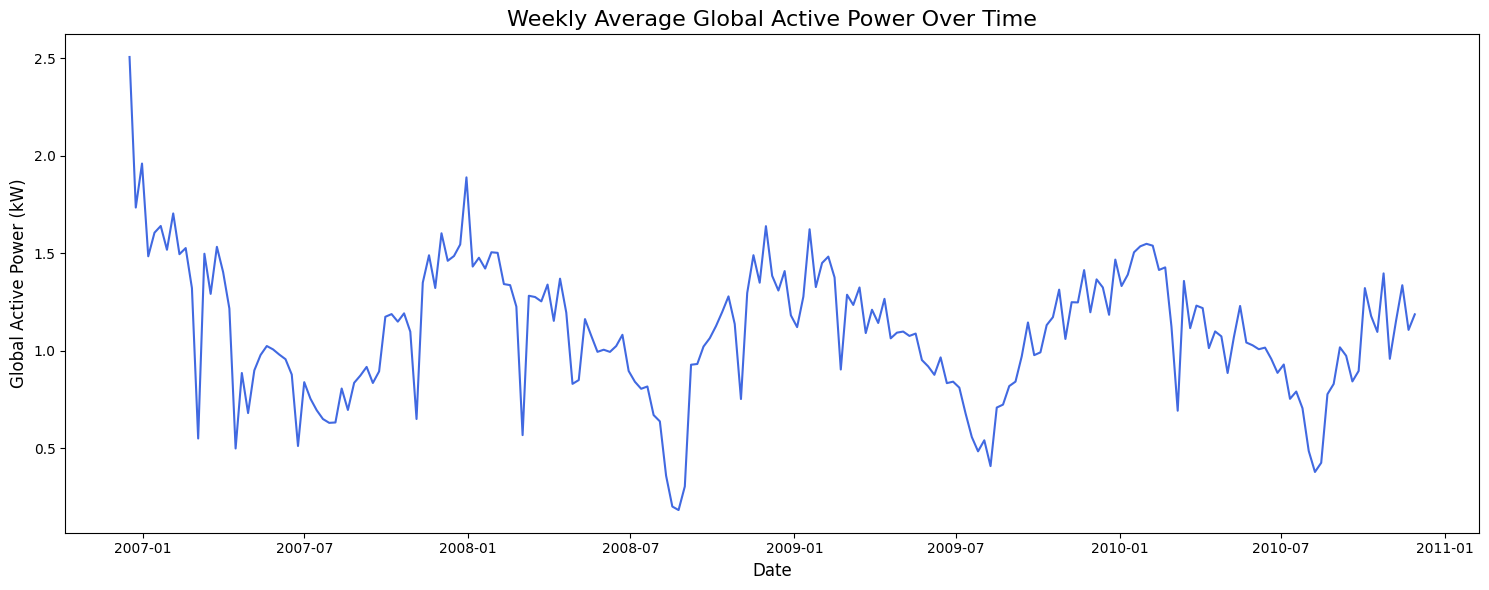

In [12]:
plt.figure(figsize=(15, 6))
# Resample data to weekly ('W') frequency and calculate the mean
daily_data = df['Global_active_power'].resample('W').mean()

plt.plot(daily_data.index, daily_data.values, color='royalblue', linewidth=1.5)
plt.title('Weekly Average Global Active Power Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Global Active Power (kW)', fontsize=12)
plt.tight_layout()
plt.show()

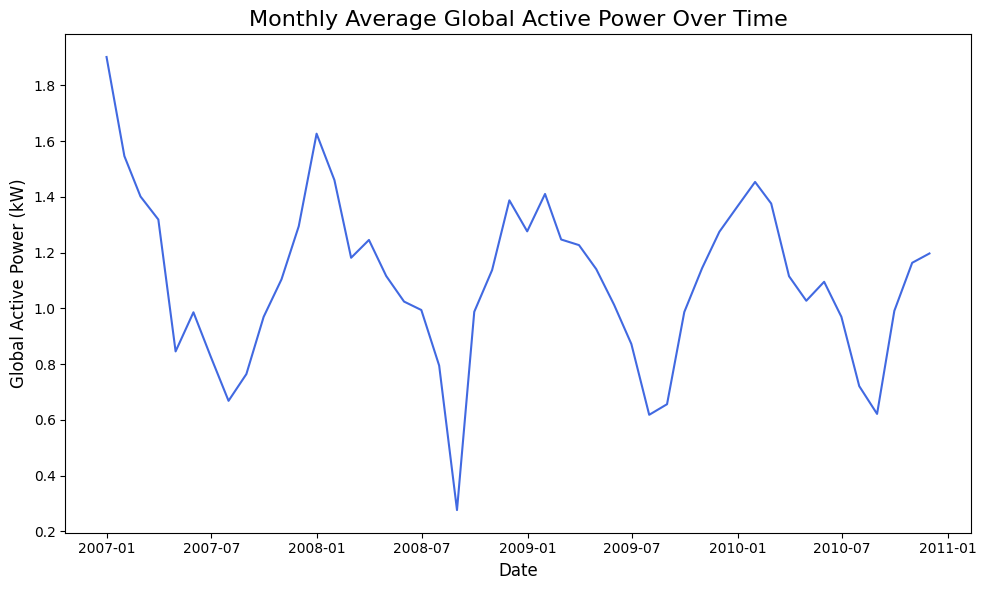

In [13]:
daily_data = df['Global_active_power'].resample('ME').mean()
plt.figure(figsize=(10, 6))
plt.plot(daily_data.index, daily_data.values, color='royalblue', linewidth=1.5)
plt.title('Monthly Average Global Active Power Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Global Active Power (kW)', fontsize=12)
plt.tight_layout()
plt.show()

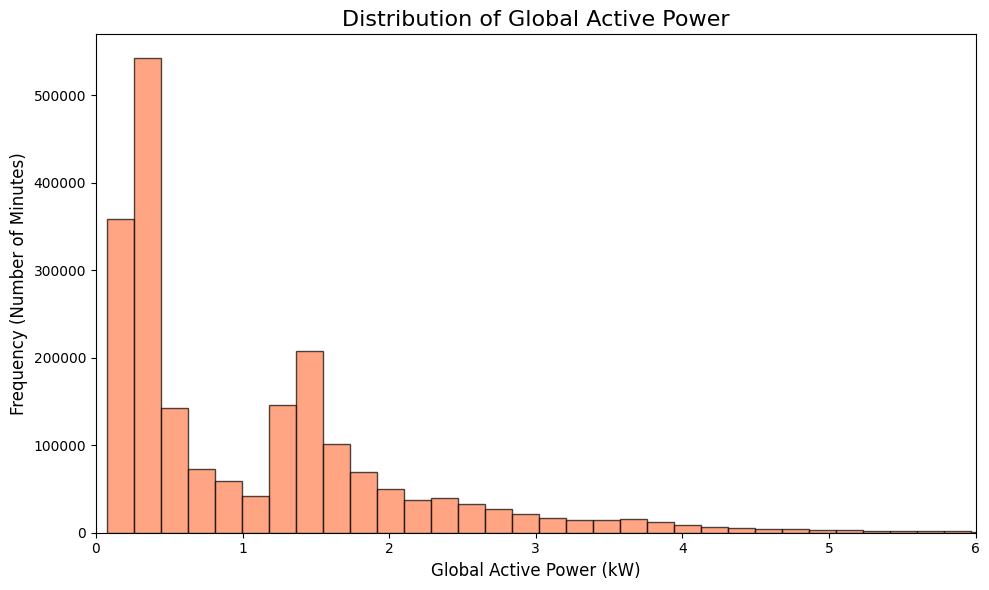

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(df['Global_active_power'], bins=60, color='coral', edgecolor='black', alpha=0.7)
plt.title('Distribution of Global Active Power', fontsize=16)
plt.xlabel('Global Active Power (kW)', fontsize=12)
plt.ylabel('Frequency (Number of Minutes)', fontsize=12)
# Limit x-axis to zoom in on the main distribution
plt.xlim(0, 6) 
plt.tight_layout()
plt.show()

C:\Users\danm\AppData\Local\Temp\ipykernel_4656\1346586384.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Hour', y='Global_active_power', data=df, showfliers=False, palette='viridis')


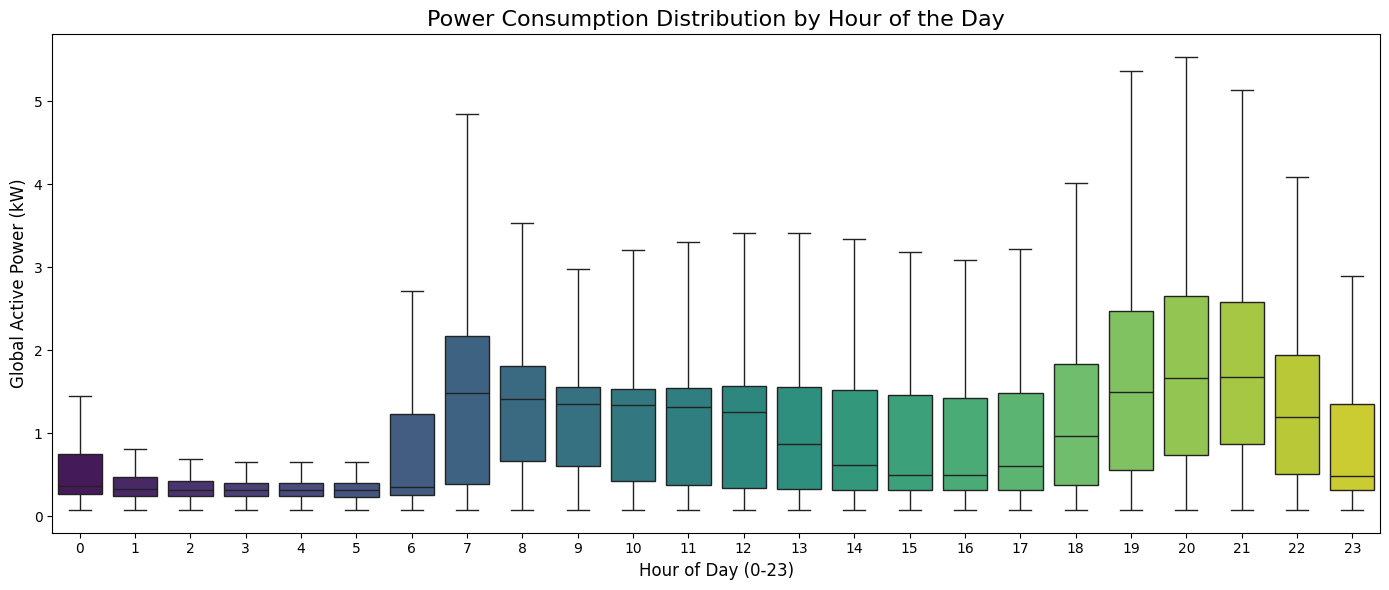

In [15]:
import seaborn as sns
df['Hour'] = df.index.hour

plt.figure(figsize=(14, 6))
# showfliers=False removes extreme outliers to make the boxes easier to read
sns.boxplot(x='Hour', y='Global_active_power', data=df, showfliers=False, palette='viridis')
plt.title('Power Consumption Distribution by Hour of the Day', fontsize=16)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Global Active Power (kW)', fontsize=12)
plt.tight_layout()
plt.show()

# Clean up the temporary column
df.drop('Hour', axis=1, inplace=True)

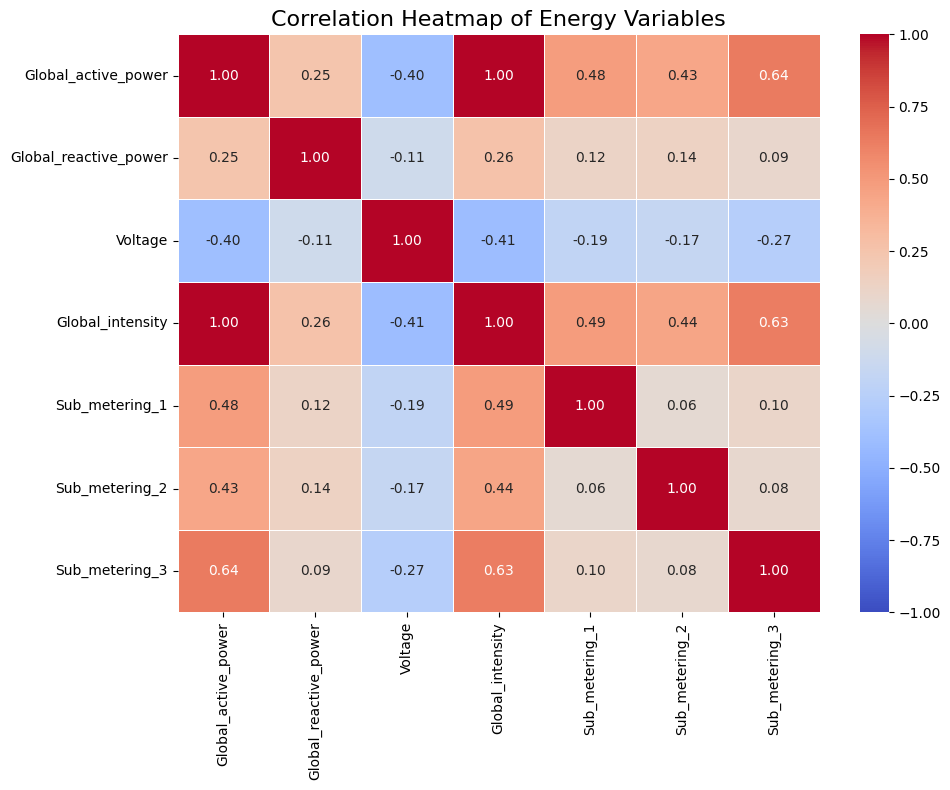

In [16]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Energy Variables', fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
df.columns

Index(['Global_active_power', 'Global_reactive_power', 'Voltage',
       'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

In [18]:
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class DataValidationConfig:
    root_dir: Path
    STATUS_FILE: str
    unzip_data_dir: Path
    all_schema: dict
    

In [19]:
from src.dlProject_energy_demand_forcasting.constants import *
from src.dlProject_energy_demand_forcasting.utils.utils import read_yaml, create_directories

In [20]:
class ConfigurationManager:
    def __init__(self, config_filepath = CONFIG_FILE_PATH,
                 params_filepath = PARAMS_FILE_PATH,
                 schema_filepath = SCHEMA_FILE_PATH):
        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)
        self.schema = read_yaml(schema_filepath)

        create_directories([self.config.artifacts_root])

    def get_data_validation_config(self) -> DataValidationConfig:
        config = self.config.data_validation
        schema = self.schema.columns

        create_directories([config.root_dir])

        data_validation_config = DataValidationConfig(
            root_dir=config.root_dir,
            STATUS_FILE= config.STATUS_FILE,
            unzip_data_dir=config.unzip_data_dir,
            all_schema=schema
        ) 

        return data_validation_config

In [21]:
import os 
import sys
import urllib.request as request
import zipfile
from src.dlProject_energy_demand_forcasting.utils.logger import logging
from src.dlProject_energy_demand_forcasting.utils.exception import CustomException
from src.dlProject_energy_demand_forcasting.utils.utils import get_size

In [ ]:
import pandas as pd
import os
import sys

class DataValidation:
    def __init__(self, config: DataValidationConfig):
        self.config = config

    def validate_all_columns(self) -> bool:
        try:
            output_dir = os.path.dirname(self.config.STATUS_FILE)
            os.makedirs(output_dir, exist_ok=True)

            validation_status = True 
            
            if not os.path.exists(self.config.unzip_data_dir):
                validation_status = False
                with open(self.config.STATUS_FILE, 'w') as f:
                    f.write(f"validation status: {validation_status} (Input file missing)")
                return validation_status

            data = pd.read_csv(self.config.unzip_data_dir, sep=';', na_values=['?'], low_memory=False)
            
            schema_dict = self.config.all_schema
            print(schema_dict)

            for col in data.columns:
                if col not in schema_dict:
                    validation_status = False
                    break
                
                expected_type = schema_dict[col]
                actual_type = str(data[col].dtype)

                if actual_type != expected_type:
                    validation_status = False
                    break

            with open(self.config.STATUS_FILE, 'w') as f:
                f.write(f"validation status: {validation_status} ({col} column or type mismatch - actual type {actual_type})")

            return validation_status

        except Exception as e:
            raise CustomException(e, sys)

In [33]:
try:
    config = ConfigurationManager()
    data_validation_config = config.get_data_validation_config()
    data_validation = DataValidation(config=data_validation_config)
    data_validation.validate_all_columns()

except Exception as e:
    raise CustomException(e, sys)

[ 2026-04-23 13:43:41,065 ] 31 root - INFO - yaml file: config\config.yaml loaded successfully
[ 2026-04-23 13:43:41,067 ] 31 root - INFO - yaml file: params.yaml loaded successfully
[ 2026-04-23 13:43:41,070 ] 31 root - INFO - yaml file: schema.yaml loaded successfully
[ 2026-04-23 13:43:41,071 ] 52 root - INFO - created directory at: artifacts
[ 2026-04-23 13:43:41,073 ] 52 root - INFO - created directory at: artifacts/data_validation


CustomException: Error occurred in script: [C:\Users\danm\AppData\Local\Temp\ipykernel_4656\1945183100.py] at line: [5] in function: [<module>()] with error message: [Error occurred in script: [C:\Users\danm\AppData\Local\Temp\ipykernel_4656\4129025878.py] at line: [24] in function: [validate_all_columns()] with error message: ["'ConfigBox' object has no attribute 'columns'"]]